## Question 1

In [1]:
import numpy as np
import util

In [2]:
data = np.random.normal(10, 2, 100)

my_mean = util.mean(data)
numpy_mean = np.mean(data)

print("My mean value:", my_mean)
print("Numpy mean value:", numpy_mean)

My mean value: 9.987795396153418
Numpy mean value: 9.987795396153421


In [3]:
my_std = util.stdev(data)
numpy_std = np.std(data)   

print("My standard deviation:", my_std)
print("Numpy standard deviation:", numpy_std)

My standard deviation: 2.073301221786673
Numpy standard deviation: 2.073301221786673


In [4]:
# create data with 2 features
data_2d = np.random.normal(0, 1, (10, 2))

print("Data:")
print(data_2d)

Data:
[[-1.15075392  0.09606502]
 [-1.12596069  0.19905432]
 [ 0.0420824  -1.50792632]
 [-0.66267478 -1.08250871]
 [ 0.1950567   1.21591005]
 [ 1.36675892  0.19626043]
 [-0.16236739  0.30280367]
 [ 0.55985889  0.98166706]
 [ 0.03381986  0.14201358]
 [-0.7201653   0.3891713 ]]


In [5]:
my_sample_mean = util.sampleMean(data_2d)
numpy_sample_mean = np.mean(data_2d, axis=0)

print("My sample mean:", my_sample_mean)
print("Numpy sample mean:", numpy_sample_mean)

My sample mean: [np.float64(-0.16243453077601697), np.float64(0.09325104083092725)]
Numpy sample mean: [-0.16243453  0.09325104]


In [6]:
my_cov = util.covariance(data_2d)
numpy_cov = np.cov(data_2d, rowvar=False, bias=True)

print("My covariance matrix:")
print(my_cov)

print("\nNumpy covariance matrix:")
print(numpy_cov)

My covariance matrix:
[[np.float64(0.5534745142232912), np.float64(0.12010683157369215)], [np.float64(0.12010683157369215), np.float64(0.6151498284974323)]]

Numpy covariance matrix:
[[0.55347451 0.12010683]
 [0.12010683 0.61514983]]


## Question 2

In [7]:
import numpy as np
import pandas as pd
from classifiers import Prior

np.random.seed(0)

# Create heart-rate values
stress_hr = np.random.normal(110, 10, 430)
not_stress_hr = np.random.normal(65, 10, 570)

# Create labels
stress_labels = np.array(["Stress"] * 430)
not_stress_labels = np.array(["Not Stress"] * 570)

# Combine
heart_rate = np.concatenate([stress_hr, not_stress_hr])
labels = np.concatenate([stress_labels, not_stress_labels])

df = pd.DataFrame({
    "Heart-Rate": heart_rate,
    "Class": labels
})

df.head()

,Heart-Rate,Class
0,127.640523,Stress
1,114.001572,Stress
2,119.787380,Stress
3,132.408932,Stress
4,128.675580,Stress


In [8]:
df.groupby("Class")["Heart-Rate"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Not Stress,570.0,64.401727,9.833614,34.538569,57.908276,64.327951,70.209880,92.593551
Stress,430.0,109.740577,9.938391,82.274072,103.104754,109.577857,116.636032,133.831448


In [9]:
clf = Prior()
x = df[["Heart-Rate"]].values   
y = df["Class"].values         

clf.fit(x, y)
print(clf.model_params)

{'priors': {'Stress': 0.43, 'Not Stress': 0.57}, 'most_common_class': 'Not Stress'}


In [10]:
test_x = np.arange(40, 141).reshape(-1, 1)
preds = clf.predict(test_x)

print(preds[:10])
print("Unique predictions:", np.unique(preds))

['Not Stress' 'Not Stress' 'Not Stress' 'Not Stress' 'Not Stress'
 'Not Stress' 'Not Stress' 'Not Stress' 'Not Stress' 'Not Stress']
Unique predictions: ['Not Stress']


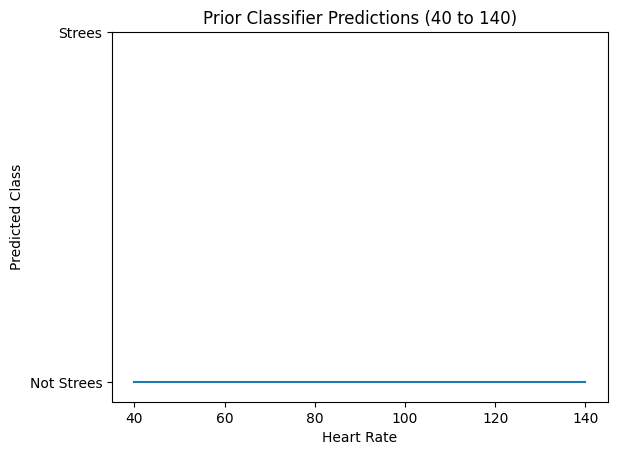

In [11]:
import matplotlib.pyplot as plt

plt.plot(test_x.flatten(), preds)
plt.xlabel("Heart Rate")
plt.ylabel("Predicted Class")
plt.yticks([0,1], ["Not Strees", "Strees"])
plt.title("Prior Classifier Predictions (40 to 140)")
plt.show()

## Question 3

### 1 P(ωj)stands for prior
### p(wj|x) posterior
### p(x|wj) likelihood
### p(x) evidence

### 2. A prior is optimum when no informarion is given for x/feature. Predicting the class with the highest prior probability minimizes classification error in this case.

### 3. A hypothesis function h(x) maps input x to an output prediction. Overfitting occurs when h(x) is too complex and fits noise in the data, while underfitting occurs when h(x) is too simple to capture patterns.

## Question 4

In [12]:
from classifiers import Prior, DiscriminantClassifier
from discriminants import GaussianDiscriminant, MultivariateGaussian

In [13]:
np.random.seed(0)

resting = np.random.normal(loc=60, scale=5, size=1000)
stressed = np.random.normal(loc=100, scale=5, size=1000)

print("Resting mean/std:", np.mean(resting), np.std(resting))
print("Stressed mean/std:", np.mean(stressed), np.std(stressed))

Resting mean/std: 59.77371646254902 4.935165793345129
Stressed mean/std: 100.06808470158083 4.840799919132115


In [14]:
g_rest = GaussianDiscriminant(data=resting, prior=0.5, name="Resting")
g_stress = GaussianDiscriminant(data=stressed, prior=0.5, name="Stressed")

print(g_rest.params)
print(g_stress.params)

{'mu': np.float64(59.77371646254902), 'sigma': np.float64(4.935165793345129), 'prior': 0.5}
{'mu': np.float64(100.06808470158083), 'sigma': np.float64(4.840799919132115), 'prior': 0.5}


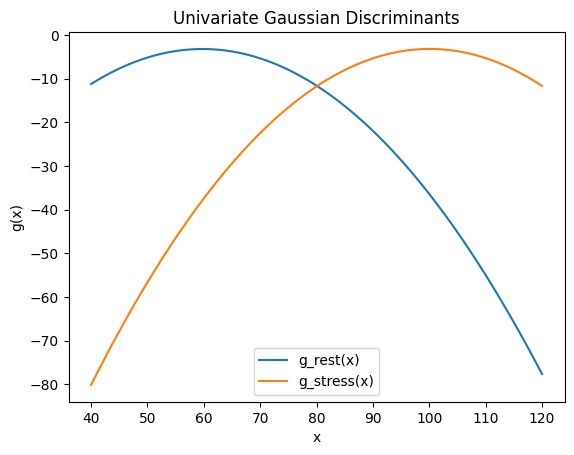

In [15]:
xs = np.arange(40, 121)

g1 = []
g2 = []

for x in xs:
    g1.append(g_rest.calc_discriminant(x))
    g2.append(g_stress.calc_discriminant(x))

plt.figure()
plt.plot(xs, g1, label="g_rest(x)")
plt.plot(xs, g2, label="g_stress(x)")
plt.xlabel("x")
plt.ylabel("g(x)")
plt.title("Univariate Gaussian Discriminants")
plt.legend()
plt.show()

In [16]:
diff = np.array(g1) - np.array(g2)

boundary_x = None
for i in range(len(xs) - 1):
    if diff[i] == 0:
        boundary_x = xs[i]
        break
    if diff[i] * diff[i+1] < 0:
        boundary_x = xs[i]
        break

print("Approx decision boundary near x =", boundary_x)

Approx decision boundary near x = 80


### Short Answer
### Because the two classes have similar variances and equal priors, the decision boundary occurs near the midpoint between their means.
### Each discriminant contains a negative quadratic term in x, which produces a downward-opening parabolic shape.

## Question 5

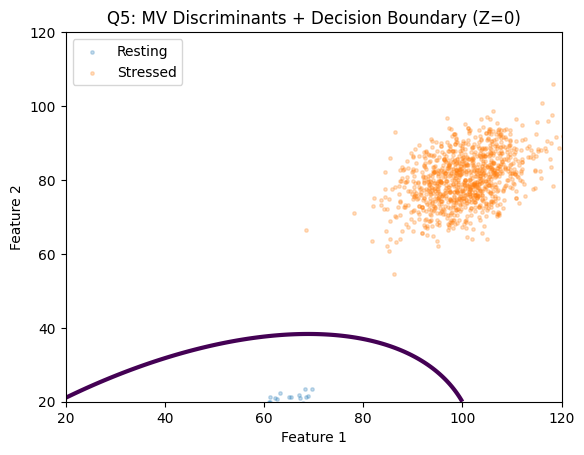

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from discriminants import MultivariateGaussian

np.random.seed(0)

mu_rest = np.array([60, 10])
sigma_rest = np.array([[20, 10],
                       [10, 20]])   

mu_stress = np.array([100, 80])
sigma_stress = np.array([[50, 20],
                         [20, 50]])

resting = np.random.multivariate_normal(mu_rest, sigma_rest, size=1000)
stressed = np.random.multivariate_normal(mu_stress, sigma_stress, size=1000)

mv_rest = MultivariateGaussian(data=resting, prior=0.5, name="Resting")
mv_stress = MultivariateGaussian(data=stressed, prior=0.5, name="Stressed")

# grid over [20,20] to [120,120]
x_vals = np.linspace(20, 120, 200)
y_vals = np.linspace(20, 120, 200)

Z = np.zeros((len(y_vals), len(x_vals)))
for i in range(len(y_vals)):
    for j in range(len(x_vals)):
        pt = np.array([x_vals[j], y_vals[i]])
        Z[i, j] = mv_rest.calc_discriminant(pt) - mv_stress.calc_discriminant(pt)

plt.figure()
plt.scatter(resting[:, 0], resting[:, 1], s=6, alpha=0.25, label="Resting")
plt.scatter(stressed[:, 0], stressed[:, 1], s=6, alpha=0.25, label="Stressed")

# decision boundary where they cross: Z = 0
plt.contour(x_vals, y_vals, Z, levels=[0], linewidths=3)

plt.xlim(20, 120)
plt.ylim(20, 120)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Q5: MV Discriminants + Decision Boundary (Z=0)")
plt.legend()
plt.show()

## Question 6

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from classifiers import DiscriminantClassifier
from discriminants import MultivariateGaussian

# ----- 1) Build a dataframe from the resting/stressed samples -----
df2 = pd.DataFrame({
    "F1": np.concatenate([resting[:, 0], stressed[:, 0]]),
    "F2": np.concatenate([resting[:, 1], stressed[:, 1]]),
    "Labels": np.array(["Resting"] * len(resting) + ["Stressed"] * len(stressed))
})

df2.head()

,F1,F2,Labels
0,52.273076,4.062633,Resting
1,51.198575,11.220154,Resting
2,54.952239,0.581719,Resting
3,56.658768,5.981878,Resting
4,59.481639,11.317891,Resting


In [19]:
# ----- 2) Fit the discriminant classifier using MV Gaussian -----
dc = DiscriminantClassifier()
dc.fit(df2, label_key=["Labels"], default_disc=MultivariateGaussian)

print(dc.model_params["classes"].keys())
print(dc.model_params["counts"])

dict_keys(['Resting', 'Stressed'])
{'Resting': 1000, 'Stressed': 1000}


In [20]:
x_vals = np.linspace(20, 120, 200)
y_vals = np.linspace(20, 120, 200)

def decision_grid(model, x_vals, y_vals):
    grid = np.zeros((len(y_vals), len(x_vals)))
    for i in range(len(y_vals)):
        for j in range(len(x_vals)):
            pt = np.array([x_vals[j], y_vals[i]])
            pred = model.predict(pt)
            if pred == "Resting":
                grid[i, j] = 0
            else:
                grid[i, j] = 1
    return grid

In [21]:
def plot_regions_and_clusters(grid, title):
    plt.figure(figsize=(7, 6))

    # background decision regions
    plt.imshow(
        grid,
        extent=[20, 120, 20, 120],
        origin="lower",
        aspect="auto",
        cmap=plt.cm.coolwarm,
        alpha=0.35
    )

    # overlay clusters
    plt.scatter(resting[:, 0], resting[:, 1], s=10, color="navy", alpha=0.5, label="Resting")
    plt.scatter(stressed[:, 0], stressed[:, 1], s=10, color="darkred", alpha=0.5, label="Stressed")
    plt.xlim(20, 120)
    plt.ylim(20, 120)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.show()

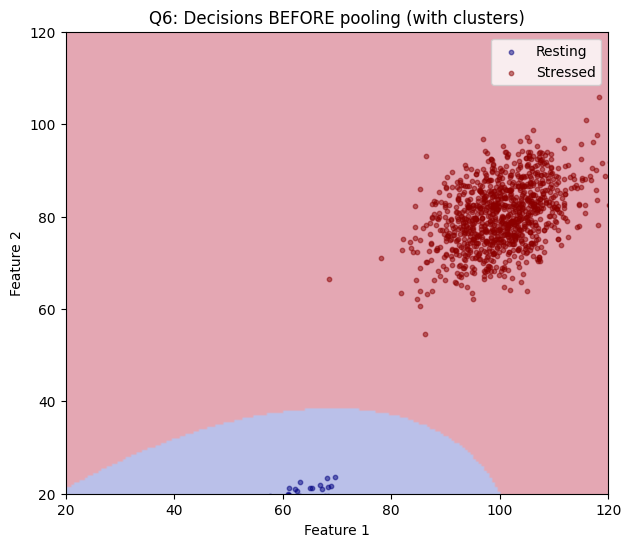

In [22]:
G_before = decision_grid(dc, x_vals, y_vals)
plot_regions_and_clusters(G_before, "Q6: Decisions BEFORE pooling (with clusters)")

### Before pooling, each class has its own covariance matrix, which results in a non-linear decision boundary.

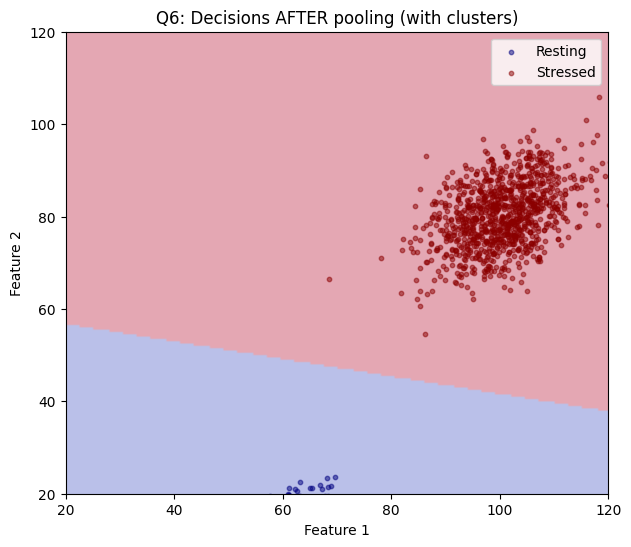

In [23]:
dc.pool_variances()

G_after = decision_grid(dc, x_vals, y_vals)
plot_regions_and_clusters(G_after, "Q6: Decisions AFTER pooling (with clusters)")

### After pooling the covariances, all classes share the same covariance matrix, producing an approximately linear decision boundary.

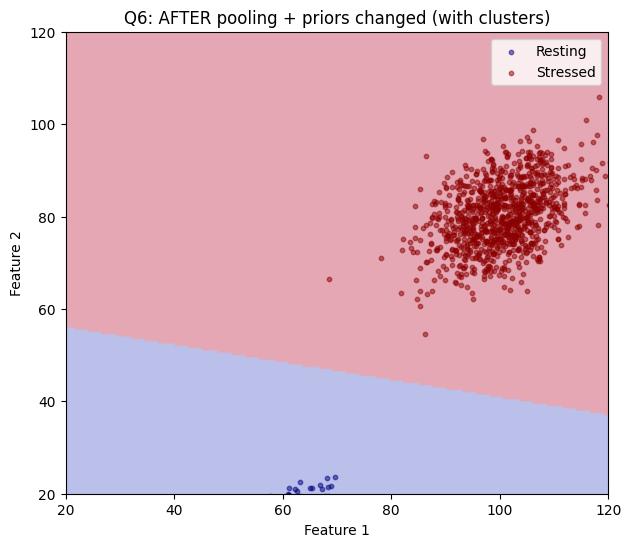

In [24]:
classes = dc.model_params["classes"]
classes["Resting"].params["prior"] = 0.2
classes["Stressed"].params["prior"] = 0.8

G_priors = decision_grid(dc, x_vals, y_vals)
plot_regions_and_clusters(G_priors, "Q6: AFTER pooling + priors changed (with clusters)")

### Increasing the prior probability of the Stressed class shifts the decision boundary to favor that class.

## Question 7

### 1. We assume data samples are independent and identically distributed (I.I.D.) so that the joint likelihood can be written as a product of individual likelihoods. This simplifies parameter estimation and allows Maximum Likelihood Estimation to be applied.

### 2. 
### Let xi ∈ {0,1} be Bernoulli(p). The likelihood is:

### L(p) = ∏_{i=1}^N p^{xi} (1-p)^{1-xi}

### Take log:

### ℓ(p) = log L(p) = ∑_{i=1}^N [xi log p + (1-xi) log(1-p)]

### Differentiate and set to 0:

### dℓ/dp = ∑_{i=1}^N [xi/p - (1-xi)/(1-p)] = 0

### Let S = ∑ xi. Then:

### S/p - (N-S)/(1-p) = 0
### S(1-p) = p(N-S)
### S = pN

### So the MLE is:

### p̂ = S/N = (1/N) ∑_{i=1}^N xi

### 3. Total balls = 3
### Θ = number of green balls
### p = Θ/3
### Observations: [1,0,0,1] → 2 ones and 2 zeros
#### The joint probability is: P(x) = (Θ/3)^2 (1 − Θ/3)^2
| Θ value | p=Θ/3 | Joint probability P(x) |
| ------- | ----: | ---------------------: |
| 0       |     0 |                      0 |
| 1       |   1/3 |  (1/3)^2(2/3)^2 = 4/81 |
| 2       |   2/3 |  (2/3)^2(1/3)^2 = 4/81 |
| 3       |     1 |                      0 |